# **DATA MODELLING**

**Mount your google drive.**

## SUPERVISED LEARNING - Regression

###1. Data - Load and Final preperation

**1.1 Read in the processed housing data set from your drive folder using pandas.**

In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv("data_processed.csv")

**1.2 View the dataset using 'display' or 'head'**

In [2]:
df.head()

,Unnamed: 0,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,...,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15,year,month,day
0,0,0.098361,0.121212,0.18750,0.120755,0.003888,0.2,0.0,0.0,0.50,...,0.165217,0.0,0.580808,0.697603,0.107973,0.223886,0.006432,0.0,0.454545,0.500000
1,1,0.087213,0.151515,0.43750,0.183396,0.006623,0.4,0.0,0.0,0.50,...,0.765217,0.0,0.257576,0.789287,0.332226,0.433832,0.012244,0.0,0.545455,0.700000
2,2,0.027410,0.090909,0.21875,0.093585,0.005500,0.0,0.0,0.0,0.50,...,0.765217,0.0,0.207071,0.327328,0.367940,0.220444,0.010372,1.0,0.181818,0.766667
3,3,0.049836,0.060606,0.12500,0.086038,0.002714,0.2,0.0,0.0,0.25,...,0.217391,0.0,0.575758,0.831269,0.182724,0.180864,0.003560,1.0,0.000000,0.866667
4,4,0.029115,0.090909,0.31250,0.105660,0.002707,0.4,0.0,0.0,0.50,...,0.886957,0.0,0.186869,0.322020,0.418605,0.246257,0.004689,0.0,0.818182,0.433333


There seems to be a extra column due to exporting the dataframe to csv, so lets remove it.

**1.3 Drop the 0 column**

In [3]:
df.drop(columns =df.columns[0],inplace=True)
df

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,...,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15,year,month,day
0,0.098361,0.121212,0.18750,0.120755,0.003888,0.2,0.0,0.0,0.50,0.583333,...,0.165217,0.000000,0.580808,0.697603,0.107973,0.223886,0.006432,0.0,0.454545,0.500000
1,0.087213,0.151515,0.43750,0.183396,0.006623,0.4,0.0,0.0,0.50,0.666667,...,0.765217,0.000000,0.257576,0.789287,0.332226,0.433832,0.012244,0.0,0.545455,0.700000
2,0.027410,0.090909,0.21875,0.093585,0.005500,0.0,0.0,0.0,0.50,0.500000,...,0.765217,0.000000,0.207071,0.327328,0.367940,0.220444,0.010372,1.0,0.181818,0.766667
3,0.049836,0.060606,0.12500,0.086038,0.002714,0.2,0.0,0.0,0.25,0.500000,...,0.217391,0.000000,0.575758,0.831269,0.182724,0.180864,0.003560,1.0,0.000000,0.866667
4,0.029115,0.090909,0.31250,0.105660,0.002707,0.4,0.0,0.0,0.50,0.500000,...,0.886957,0.000000,0.186869,0.322020,0.418605,0.246257,0.004689,0.0,0.818182,0.433333
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21608,0.114754,0.090909,0.40625,0.208302,0.011129,0.0,1.0,1.0,0.75,0.583333,...,0.539130,0.000000,0.994949,0.373492,0.160299,0.132679,0.080779,0.0,0.454545,0.633333
21609,0.113443,0.121212,0.31250,0.216604,0.023891,0.0,0.0,0.0,0.50,0.750000,...,0.695652,0.000000,0.020202,0.781567,0.300664,0.602478,0.041115,0.0,0.545455,0.933333
21610,0.085902,0.121212,0.28125,0.143396,0.005142,0.4,0.0,0.0,0.75,0.583333,...,0.669565,0.000000,0.161616,0.861670,0.274917,0.308209,0.011028,1.0,0.181818,0.333333
21611,0.235410,0.151515,0.50000,0.318491,0.008877,0.4,0.0,0.0,0.50,0.750000,...,0.600000,0.993548,0.196970,0.603185,0.241694,0.535364,0.014760,0.0,0.363636,0.166667


Now we have a dataset that is in the correct format and has already been explored a bit during a previous prac.


---



In the excersie after the presentaion we talked about a data set about property sales. We concluded that to create a model to determine the sale price for the given input we would use regression.

**1.4 TEST/TRAIN split**

Since we want to predict the price, lets set our target or 'y' as the price and then remove it from the dataset (X).

y = f(X)

In [4]:
y=df["price"]
x=df.drop(columns="price")

Next we have to **split our dataset** (X) and target (y) into the training and testing data set using the sklearn.model_selection ["train_test_split"](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html) function.

In [25]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(
x, y, test_size=0.33, random_state=12)

###2. Linear Regression

If we think back on the visualistion that we did on this dataset in day 2, we saw some linear relationships between variables.

So lets see how well a linear regression model will do.

**Import the machine learning package LinearRegression from the library 'sklearn'**

In [26]:
from sklearn.linear_model import LinearRegression

**Set your model**

In [29]:
model = LinearRegression()

**Fit the model** to the training data.

In [30]:
model.fit(x_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](21,)","[-0.18, 0.04, 0.12,..., 0.01, 0. ,-0. ]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](21,)","['bedrooms','bathrooms','sqft_living',...,'year','month','day']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-0.06699
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,21
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,20


Finaly use the fitted model to **predict the test price** and calculate the accuracy by using "score".

In [31]:
model.predict(x_test)

array([0.04019408, 0.01287392, 0.05966266, ..., 0.14130676, 0.07183382,
       0.07881215], shape=(7133,))

In [32]:
model.score(x_test,y_test)

0.708296064392905

Grab a sample (row) from the test set so that you can do a prediction.

In [33]:
x_demo = x_test.iloc[5].values.reshape(1,-1)
y_demo = y_test.iloc[5]

Predict the house price for X_demo

In [12]:
y_pred=model.predict(x_demo)


C:\Users\Senzwa4\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


Lets see if we can try another algorithms what will let us do some parameter tuning, such as support vector regression.

###3. Non-Linear Regression

Since we want to do some parameter tuning, we do not want to tune the parameters using the testing set. Do you know why?

**Set up a [XGBoot regressor](https://machinelearningmastery.com/xgboost-for-regression/)** with parameters: n_estimators=10, max_depth=5, eta=0.01, subsample=0.7, colsample_bytree=0.8.

In [18]:
!pip install xgboost
import xgboost as xgb

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [19]:
mod= xgb.XGBRegressor(n_estimators=10, max_depth=5, eta=0.01, subsample=0.7, colsample_bytree=0.8)

Fit the model with the training data.

In [20]:
mod.fit(x_train,y_train)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


Calculate the acuracy of the model using the training data.

In [22]:
mod.score(x_test,y_test)

0.12144269200367663

### 4. Hyperparameter Tuning
The next step would be to tune the parameters to get a better result. BUT this can't just be done by changing the values and looking at the test scores, since that may leed to overfitting.

Hence **[cross validation](https://scikit-learn.org/stable/modules/cross_validation.html) should be employed**, using the "cross_validate" sklearn.model_selection function.

Once the cross validation is incorporated, more information on the parameters that can be tuned can be found [here](https://www.geeksforgeeks.org/machine-learning/xgboost-for-regression/).

Change the parameters and see how the score changes. **TIP**: don't 'fine tune' the parameters, rather change the order of magnitude e.g. eta=0.01, 0.1, 1, etc.

In [50]:
from sklearn.model_selection import cross_validate
mod= xgb.XGBRegressor(n_estimators=200, max_depth=5, eta=0.01, subsample=0.7, colsample_bytree=0.8)
cv_results = cross_validate(mod,x,y,cv=5)
cv_results["test_score"]
print(np.mean(cv_results["test_score"]))

0.8128402969724166


In [54]:
from sklearn.model_selection import cross_val_score
mod1= xgb.XGBRegressor(n_estimators=1000, max_depth=5, eta=0.01, subsample=0.7, colsample_bytree=0.8)
score = cross_val_score(mod1,x_train,y_train,cv=5)
print(np.mean(score))


0.8838045119053733


Once you are satified with the validation test score, fit the model to the training data and view the score of the test set.

In [55]:
mod1.fit(x_train,y_train)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [56]:
mod1.score(x_test,y_test)

0.8873329216423289

### 5. Feature Importance
Which features were the most influencial in the prediction? Hint: [Feature importance](https://machinelearningmastery.com/10-python-one-liners-for-calculating-model-feature-importance/).

In [57]:
important = mod1.feature_importances_

Let's plot the importance using matplotlib barh.

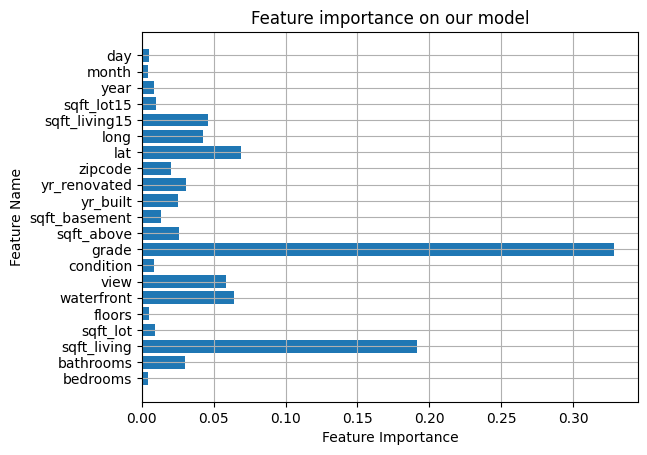

In [75]:
import matplotlib.pyplot as mplt

mplt.barh(x.columns,important)
mplt.xlabel("Feature Importance")
mplt.ylabel("Feature Name")
mplt.title("Feature importance on our model")
mplt.grid()

## SUPERVISED LEARNING - Classification

Lets look at a very simple example for classification.

**Download the (famous) iris dataset** using seaborn

This dataset is already cleaned, so we don't have to check for missing values or outliers. But we will have to
1. Load and look at data so that you can better understand it,
2. Process the data
   - Normalise (just to be safe - it's good practice),
   - Lable encoding,
   - Encode the strings,
   - randomise and split
3. Select and Build the Model.
4. Evaluate the Model.

###1. Look at the data.

Import seaborn and load 'iris' data

In [79]:
import seaborn as sns
iris=sns.load_dataset("iris")

Inspect the data. You can use print and describe().

In [83]:
print(iris)
iris.describe()

     sepal_length  sepal_width  petal_length  petal_width    species
0             5.1          3.5           1.4          0.2     setosa
1             4.9          3.0           1.4          0.2     setosa
2             4.7          3.2           1.3          0.2     setosa
3             4.6          3.1           1.5          0.2     setosa
4             5.0          3.6           1.4          0.2     setosa
..            ...          ...           ...          ...        ...
145           6.7          3.0           5.2          2.3  virginica
146           6.3          2.5           5.0          1.9  virginica
147           6.5          3.0           5.2          2.0  virginica
148           6.2          3.4           5.4          2.3  virginica
149           5.9          3.0           5.1          1.8  virginica

[150 rows x 5 columns]


,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


Visualise the data using a seaborn [swarm plot](https://seaborn.pydata.org/generated/seaborn.swarmplot.html).


Set x equal to 'species' and select any one of the other parameters (one of the feature vectors) as y in the plot.

<Axes: xlabel='species', ylabel='petal_length'>

C:\Users\Senzwa4\AppData\Roaming\Python\Python313\site-packages\seaborn\categorical.py:3399: UserWarning: 12.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


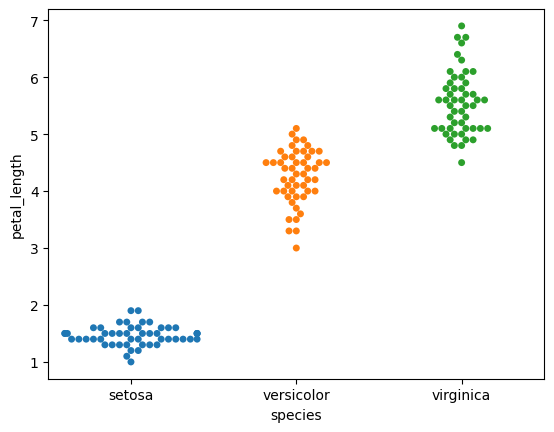

In [86]:
sns.swarmplot(data=iris,x="species",y="petal_length",hue='species')

<Axes: xlabel='species', ylabel='sepal_width'>

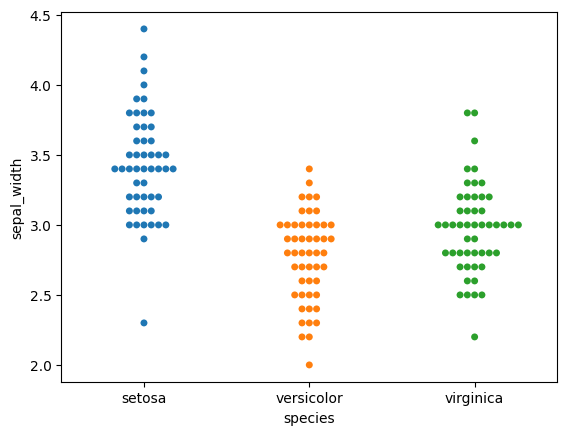

In [87]:
sns.swarmplot(data=iris,x="species",y="sepal_width",hue='species')

###2. Process the data

Let us now roughly follow the procedure from the previous excersise starting with **identifying and setting X and y**.

In [105]:
y=iris['species']
x=iris.drop(columns='species')

Normalise X using MinMaxScaler.

In [104]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
scaler.fit(x)
X_norm = scaler.transform(x)

This dataset contains strings (in the species column) and so have to be set to integers.
Instead of doing this manualy, a [Label Encoder](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.LabelEncoder.html) can be used.

In [103]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
le.fit(y)
Y_transform = le.transform(y)
print(Y_transform)

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2]


Divide the data into the **train and test** set using test_size=0.3.

In [107]:
x_train, x_test, y_train, y_test = train_test_split(X_norm, Y_transform, test_size=0.33, random_state=1)

###3. Select and Build the Model

Select and set up a classifier (Ransom Forest).

In [119]:
from sklearn.ensemble import RandomForestClassifier
clf = RandomForestClassifier(n_estimators=100)

 Train the dataset using cross_validation and tune the hyperparameters (number of estimators).

In [121]:
from sklearn.model_selection import cross_validate
cross_val = cross_validate(clf,x_train,y_train,cv = 5)
cross_val
result = np.mean(cross_val['test_score'])
print(f"{result:.2f}")

0.94


Fit the model with the optimal parameters and predict the test set (X_test).

In [123]:
trainedMod=clf.fit(x_train,y_train)
y_pred =trainedMod.predict(x_test)

###4. Evaluate the Model

Calculate the [F1 score](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.f1_score.html).

In [131]:
from sklearn.metrics import f1_score
f1_score(y_test, y_pred, average='weighted')

0.96

Lets plot the [confusion matrix](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.ConfusionMatrixDisplay.html) to get a visual on the model performance.

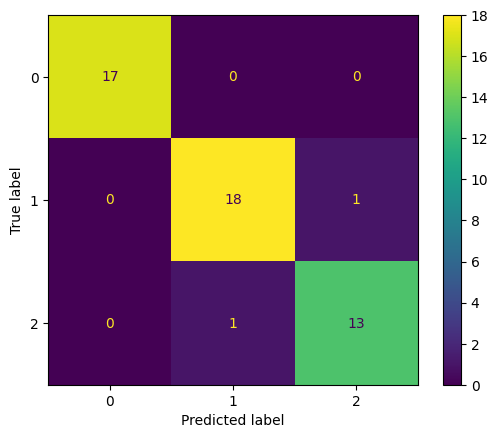

In [134]:
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_estimator(clf, x_test, y_test)